<center><img src="images/clothing.jpg"></center>

Welcome to the world of e-commerce, where customer feedback is a goldmine of insights! In this project, you'll dive into the Women's Clothing E-Commerce Reviews dataset, focusing on the 'Review Text' column filled with direct customer opinions.

Your mission is to use text embeddings and Python to analyze these reviews, uncover underlying themes, and understand customer sentiments. This analysis will help improve customer service and product offerings.

## The Data

You will be working with a dataset specifically focusing on customer reviews. Below is the data dictionary for the relevant field:

## womens_clothing_e-commerce_reviews.csv

| Column        | Description                           |
|---------------|---------------------------------------|
| `'Review Text'` | Textual feedback provided by customers about their shopping experience and product quality. |

Armed with access to powerful embedding API services, you will process the reviews, extract meaningful insights, and present your findings.

Let's get started!

## Install useful libraries

In [1]:
# Run this cell to install ChromaDB if desired
try:
    assert version('chromadb') == '0.4.17'
except:
    !pip install chromadb==0.4.17
try:
    assert version('pysqlite3') == '0.5.2'
except:
    !pip install pysqlite3-binary==0.5.2
__import__('pysqlite3')
import sys
sys.modules['sqlite3'] = sys.modules.pop('pysqlite3')
import chromadb

Defaulting to user installation because normal site-packages is not writeable
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
embedchain 0.1.113 requires chromadb<0.5.0,>=0.4.24, but you have chromadb 0.4.17 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 108.4 MB/s eta 0:00:00

[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## Load the dataset
Load data and perform basic data checks to ensure you are using relevant data for the analysis

In [2]:
# Load the dataset
import pandas as pd
reviews = pd.read_csv("womens_clothing_e-commerce_reviews.csv")

# Display the first few entries
reviews.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [21]:
from openai import OpenAI
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

In [13]:
client = OpenAI()

In [36]:
# extract non empty review text entries
reviews_clean = reviews.dropna(subset='Review Text', inplace=False)

In [37]:
# sanity check
assert reviews_clean['Review Text'].isna().sum() == 0

In [38]:
# compute embeddings for a list of text strings
def get_embeddings(texts, model="text-embedding-3-small"):
    response = client.embeddings.create(
        input = texts,
        model = model)
    
    return [entry.embedding for entry in response.data]

In [39]:
# response = client.embeddings.create(
#     model="text-embedding-3-small",
#     input=reviews_clean['Review Text']
# )

In [40]:
# response_dict = response.model_dump()

In [41]:
embeddings = get_embeddings(reviews_clean['Review Text'])

In [42]:
assert len(reviews_clean) == len(embeddings)

In [53]:
# apply dimensionality reduction on the embeddings
tsne = TSNE(n_components=2, perplexity=5)
embeddings_2d = tsne.fit_transform(np.array(embeddings))

In [70]:
# sanity check
assert len(embeddings_2d) == len(reviews_clean)

In [75]:
reviews_clean.head()

,Review ID,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Review Embedding,Review Embedding 2D
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates,"[0.025604248046875, -0.049835205078125, -0.086...","(48.02779, 7.314147)"
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses,"[0.01287841796875, -0.0147857666015625, -0.035...","(21.782145, 35.17286)"
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses,"[0.0260467529296875, 0.0537109375, -0.02214050...","(-10.652751, 28.644138)"
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants,"[0.0313720703125, -0.0022792816162109375, -0.0...","(-1.7740688, 72.49275)"
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses,"[0.0330810546875, 0.003993988037109375, -0.013...","(23.381847, -31.869516)"


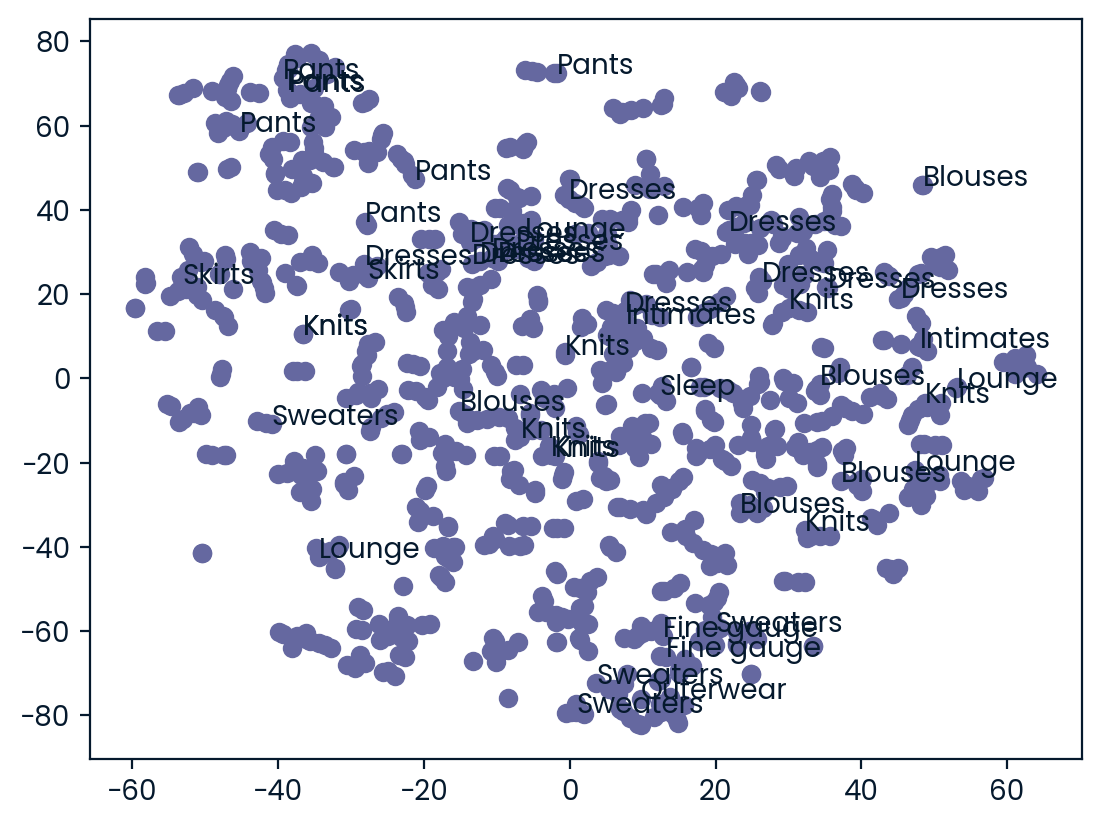

In [73]:
plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])

for i, class_name in reviews_clean['Class Name'].head(50).items():
    plt.annotate(class_name, (embeddings_2d[i,0], embeddings_2d[i,1]))
plt.show()